# LeWorldModel Hacking 9 — CEM Visualization (with rollout + re-plan)

Four sections:
1. **Explore** which episode and goal offset to plan over (now supporting `goal_offset > 25`).
2. **Run** instrumented CEM on the chosen config, visualize, and save everything to disk for the manim animation.
3. **Execute** the resulting plan in the real env, save every rendered frame.
4. **Re-plan** from the new env state and save in the same format as the first plan.


## Setup (run once)

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import json
import time
from pathlib import Path
from copy import deepcopy
from collections import defaultdict
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse

import torch
import gymnasium as gym
from sklearn.preprocessing import StandardScaler
from torchvision.transforms import v2 as transforms

import stable_pretraining as spt
import stable_worldmodel as swm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("cache: ", swm.data.utils.get_cache_dir())


/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu
cache:  /home/stephen/.stable_worldmodel


### Color mapping

In [1]:
DEFAULT_PALETTE: dict = {
    # ── source anchors (sampled by hand from the PushT renderer) ─────────
    "src_bg":            np.array([254, 254, 254], dtype=np.float32),
    "src_frame_border":  np.array([197,	197,	197		], dtype=np.float32),
    "src_target_fill":   np.array([91,	229,	104	], dtype=np.float32),  # green T
    "src_movable_fill":  np.array([92,	121,	147	], dtype=np.float32),  # blue-gray T
    "src_effector_fill": np.array([11,	78,	248	], dtype=np.float32),  # blue dot
    "src_target_outline":   np.array([104,	231,	115	], dtype=np.float32),  # green T
    "src_movable_outline":  np.array([64,	85,	106	], dtype=np.float32),  # blue-gray T
    "src_effector_outline": np.array([11,	65,	212	], dtype=np.float32),  # blue dot
    
    # ── target colors ────────────────────────────────────────────────────
    "tgt_bg":               BLACK,
    "tgt_frame_border":     BLACK,
    "tgt_target_fill":      CHILL_BROWN,
    "tgt_target_outline":   CHILL_BROWN, # * 0.55,
    "tgt_movable_fill":     BLUE,
    "tgt_movable_outline":  BLUE * 0.75,
    "tgt_effector_fill":    YELLOW,
    "tgt_effector_outline": YELLOW,
 
    # ── fill-mask thresholds (loose color-ball radii) ────────────────────
    # Only used to seed the Voronoi label propagation; doesn't need to be tight.
    "r_target_fill":   45.0,
    "r_movable_fill":  22.0,
    "r_effector_fill": 55.0,
 
    # ── connected-component cleanup ──────────────────────────────────────
    # Drop fill-mask components smaller than this many pixels (kills stray AA
    # pixels that happen to fall inside a fill color ball).
    "min_component_size": 10,
}
 


DECODED_PALETTE: dict = {
    # ── source anchors (sampled by hand from the PushT renderer) ─────────
    "src_bg":            np.array([203,	214,	226	], dtype=np.float32),
    "src_frame_border":  np.array([156,	164,	178	], dtype=np.float32),
    # "src_target_fill":   np.array([64,	184,	93	], dtype=np.float32),  # green T
    "src_target_fill":   np.array([88,	201,	112	], dtype=np.float32),  # green T
    
    # "src_movable_fill":  np.array([69,	100,	137	], dtype=np.float32),  # blue-gray T
    "src_movable_fill":  np.array([92,	121,	147	], dtype=np.float32),  # blue-gray T

    "src_effector_fill": np.array([ 15,	69,	215	], dtype=np.float32),  # blue dot
    "src_target_outline":   np.array([87,	172,	115	], dtype=np.float32),  # green T
    "src_movable_outline":  np.array([53,	77,	103	], dtype=np.float32),  # blue-gray T
    "src_effector_outline": np.array([14,	61,	175	], dtype=np.float32),  # blue dot
 
    # ── target colors ────────────────────────────────────────────────────
    "tgt_bg":               BLACK,
    "tgt_frame_border":     BLACK,
    "tgt_target_fill":      CHILL_BROWN,
    "tgt_target_outline":   CHILL_BROWN, # * 0.55,
    "tgt_movable_fill":     BLUE,
    "tgt_movable_outline":  BLUE * 0.75,
    "tgt_effector_fill":    YELLOW,
    "tgt_effector_outline": YELLOW,
 
    # ── fill-mask thresholds (loose color-ball radii) ────────────────────
    # Only used to seed the Voronoi label propagation; doesn't need to be tight.
    "r_target_fill":   45.0,
    "r_movable_fill":  22.0,
    "r_effector_fill": 55.0,
 
    # ── connected-component cleanup ──────────────────────────────────────
    # Drop fill-mask components smaller than this many pixels (kills stray AA
    # pixels that happen to fall inside a fill color ball).
    "min_component_size": 10,
}
 
 
# Per-shape (label_id, fill_src_key, outline_src_key, fill_tgt_key, outline_tgt_key)
_SHAPES = [
    (1, "src_target_fill",   "src_target_outline",   "tgt_target_fill",   "tgt_target_outline"),
    (2, "src_movable_fill",  "src_movable_outline",  "tgt_movable_fill",  "tgt_movable_outline"),
    (3, "src_effector_fill", "src_effector_outline", "tgt_effector_fill", "tgt_effector_outline"),
]
 
 
def _keep_largest_components(mask: np.ndarray, min_size: int) -> np.ndarray:
    """Drop connected components smaller than min_size pixels."""
    lab, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = ndi.sum_labels(mask, lab, range(1, n + 1))
    keep = np.zeros(n + 1, dtype=bool)
    keep[1:] = sizes >= min_size
    return keep[lab]
 
 
def _segment_shapes(img: np.ndarray, p: dict) -> np.ndarray:
    """Per-pixel shape label via threshold + cleanup + Voronoi propagation."""
    def ball(anchor, r):
        return np.linalg.norm(img - anchor, axis=-1) < r
 
    min_sz = int(p["min_component_size"])
    labels = np.zeros(img.shape[:2], dtype=np.int32)
    labels[_keep_largest_components(ball(p["src_target_fill"],   p["r_target_fill"]),   min_sz)] = 1
    labels[_keep_largest_components(ball(p["src_movable_fill"],  p["r_movable_fill"]),  min_sz)] = 2
    labels[_keep_largest_components(ball(p["src_effector_fill"], p["r_effector_fill"]), min_sz)] = 3
 
    if (labels == 0).all():
        # Pure-background frame; return zeros — output will be BLACK everywhere via bg anchor.
        return labels
 
    _, idx = ndi.distance_transform_edt(labels == 0, return_indices=True)
    return labels[idx[0], idx[1]]
 
 
def recolor_pusht(
    frame: np.ndarray,
    palette: dict | None = None,
    sigma: float = 22.0,
) -> np.ndarray:
    """Recolor one PushT frame.
 
    Args:
        frame:   (H, W, 3) uint8 RGB array.
        palette: dict matching DEFAULT_PALETTE structure (or None for defaults).
        sigma:   Gaussian σ in RGB units. 12 = very crisp, 22 = default, 35 = soft.
 
    Returns:
        (H, W, 3) uint8 RGB array.
    """
    p = palette if palette is not None else DEFAULT_PALETTE
    img = frame.astype(np.float32)
    H, W, _ = img.shape
 
    # 1. Spatial label per pixel
    lbl = _segment_shapes(img, p)
 
    # 2. Per-pixel fill/outline anchors based on shape label
    src_fill_pp    = np.empty_like(img)
    src_outline_pp = np.empty_like(img)
    tgt_fill_pp    = np.empty_like(img)
    tgt_outline_pp = np.empty_like(img)
    for lbl_val, sf_key, so_key, tf_key, to_key in _SHAPES:
        m = (lbl == lbl_val)
        if not m.any():
            continue
        src_fill_pp[m]    = p[sf_key]
        src_outline_pp[m] = p[so_key]
        tgt_fill_pp[m]    = p[tf_key]
        tgt_outline_pp[m] = p[to_key]
 
    # Fallback: if no shape was detected anywhere, point the shape anchors at bg
    # so they don't contribute spurious color via uninitialized memory.
    if (lbl == 0).any():
        src_fill_pp[lbl == 0]    = p["src_bg"]
        src_outline_pp[lbl == 0] = p["src_bg"]
        tgt_fill_pp[lbl == 0]    = p["tgt_bg"]
        tgt_outline_pp[lbl == 0] = p["tgt_bg"]
 
    # 3. Global bg + frame_border anchors broadcast to per-pixel shape
    bg_src    = np.broadcast_to(p["src_bg"],           img.shape)
    bg_tgt    = np.broadcast_to(p["tgt_bg"],           img.shape)
    frame_src = np.broadcast_to(p["src_frame_border"], img.shape)
    frame_tgt = np.broadcast_to(p["tgt_frame_border"], img.shape)
 
    src_pp = np.stack([src_fill_pp, src_outline_pp, bg_src, frame_src], axis=-2)  # (H, W, 4, 3)
    tgt_pp = np.stack([tgt_fill_pp, tgt_outline_pp, bg_tgt, frame_tgt], axis=-2)
 
    # 4. Gaussian soft blend over the 4 anchors
    d2 = ((img[..., None, :] - src_pp) ** 2).sum(-1)            # (H, W, 4)
    w  = np.exp(-d2 / (2.0 * sigma * sigma))
    w /= w.sum(-1, keepdims=True)
    out = (w[..., None] * tgt_pp).sum(-2)                        # (H, W, 3)
 
    return np.clip(out, 0, 255).astype(np.uint8)

NameError: name 'np' is not defined

### Setup

In [2]:
# --- env + dataset ----------------------------------------------------------
env = gym.make("swm/PushT-v1", render_mode="rgb_array")

ds = swm.data.HDF5Dataset(name="pusht_expert_train",
                          keys_to_cache=["action", "proprio", "state"])
ep_starts = np.concatenate([[0], np.cumsum(ds.lengths)]).astype(np.int64)

print(f"episodes:       {len(ds.lengths)}")
print(f"samples:        {len(ds)}")
print(f"ep length:      min={ds.lengths.min()}  median={int(np.median(ds.lengths))}  max={ds.lengths.max()}")


20:40:35.963 | INFO    (3370556, stable_pretraining) | Cached 'action' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
20:40:35.976 | INFO    (3370556, stable_pretraining) | Cached 'proprio' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
20:40:35.994 | INFO    (3370556, stable_pretraining) | Cached 'state' from '/home/stephen/.stable_worldmodel/pusht_expert_train.h5'
episodes:       18685
samples:        2336736
ep length:      min=49  median=123  max=246


In [3]:
# --- action scaler + empirical px/action calibration ------------------------
# action_scaler  : standardize/unstandardize action samples from CEM
# act_scale      : how many PushT-native pixels does one normalized action unit move
#                  the pusher (separate per x, y). Fit via 1D LS Δstate ≈ K · action.

all_actions = ds.get_col_data("action")
if all_actions.ndim == 3:
    all_actions = all_actions.reshape(-1, all_actions.shape[-1])
all_actions = all_actions[~np.isnan(all_actions).any(axis=1)]
action_scaler = StandardScaler().fit(all_actions)

EP_FOR_K = 0
row0_K = int(ep_starts[EP_FOR_K])
len_K  = int(ds.lengths[EP_FOR_K])

states_raw  = ds.get_col_data("state")
actions_raw = ds.get_col_data("action")
a_per_row   = actions_raw.sum(axis=1) if actions_raw.ndim == 3 else actions_raw

agent_xy_512 = states_raw[row0_K:row0_K + len_K, :2].astype(np.float64)
acts_ep      = a_per_row[row0_K:row0_K + len_K].astype(np.float64)
ok = ~(np.isnan(agent_xy_512).any(1) | np.isnan(acts_ep).any(1))
agent_xy_512, acts_ep = agent_xy_512[ok], acts_ep[ok]
deltas = np.diff(agent_xy_512, axis=0)
acts   = acts_ep[:-1]

K_x = (acts[:, 0] @ deltas[:, 0]) / (acts[:, 0] @ acts[:, 0])
K_y = (acts[:, 1] @ deltas[:, 1]) / (acts[:, 1] @ acts[:, 1])
act_scale = np.array([K_x, K_y])

pred   = acts * act_scale
ss_res = ((deltas - pred) ** 2).sum()
ss_tot = ((deltas - deltas.mean(0)) ** 2).sum()
print(f"act_scale (PushT px / norm. unit): x={K_x:.3f}  y={K_y:.3f}   R²={1 - ss_res/ss_tot:.4f}")

PUSHT_NATIVE = 512
IMG_SIZE     = 224
SCALE        = IMG_SIZE / PUSHT_NATIVE   # 0.4375


act_scale (PushT px / norm. unit): x=40.050  y=39.550   R²=0.9879


In [5]:
import sys
sys.path.append('/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/le-wm')

In [6]:
# --- image transform + cost model -------------------------------------------
img_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(**spt.data.dataset_stats.ImageNet),
    transforms.Resize(size=IMG_SIZE),
])

cost_model = swm.policy.AutoCostModel("pusht/lewm").to(DEVICE).eval()
cost_model.requires_grad_(False)
cost_model.interpolate_pos_encoding = True   # lets us use non-default horizons

# Callables to drive the env into a chosen dataset state at reset time.
CALLABLES = [
    {"method": "_set_state",      "args": {"state":      {"value": "state"}}},
    {"method": "_set_goal_state", "args": {"goal_state": {"value": "state"}}},
]


In [7]:
# --- episode helpers --------------------------------------------------------
def episode_info(episode_idx):
    return int(ep_starts[episode_idx]), int(ds.lengths[episode_idx])

def max_goal_offset(episode_idx, start_step=0):
    """Largest goal_offset that still fits inside the episode."""
    _, length = episode_info(episode_idx)
    return length - 1 - start_step

def render_frame(row):
    """Render frame at absolute dataset row -> (H, W, 3) uint8."""
    return ds[row]["pixels"].squeeze(0).permute(1, 2, 0).cpu().numpy()

def preview_episode(episode_idx, start_step=0, goal_offset=25, show_middle=True):
    row0, length = episode_info(episode_idx)
    if start_step + goal_offset >= length:
        raise ValueError(
            f"ep {episode_idx} length={length}, can't reach "
            f"start+offset={start_step + goal_offset}"
        )
    if show_middle:
        rows   = [row0 + start_step,
                  row0 + start_step + goal_offset // 2,
                  row0 + start_step + goal_offset]
        titles = [f"start t={start_step}",
                  f"mid   t={start_step + goal_offset // 2}",
                  f"goal  t={start_step + goal_offset}"]
    else:
        rows   = [row0 + start_step, row0 + start_step + goal_offset]
        titles = [f"start t={start_step}", f"goal  t={start_step + goal_offset}"]

    fig, axs = plt.subplots(1, len(rows), figsize=(3 * len(rows), 3))
    for ax, r, t in zip(axs, rows, titles):
        ax.imshow(render_frame(r)); ax.set_title(t); ax.axis("off")
    plt.suptitle(f"episode {episode_idx}   (length={length})")
    plt.tight_layout(); plt.show()

def preview_grid(specs):
    """specs is a list of (episode_idx, start_step, goal_offset)."""
    n = len(specs)
    fig, axs = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1: axs = axs[None, :]
    for i, (ep, st, off) in enumerate(specs):
        row0, length = episode_info(ep)
        if st + off >= length:
            axs[i, 0].text(0.5, 0.5, f"ep {ep} too short ({length})",
                           ha="center", va="center"); axs[i, 0].axis("off")
            axs[i, 1].axis("off"); continue
        axs[i, 0].imshow(render_frame(row0 + st))
        axs[i, 0].set_title(f"ep {ep}  start t={st}"); axs[i, 0].axis("off")
        axs[i, 1].imshow(render_frame(row0 + st + off))
        axs[i, 1].set_title(f"ep {ep}  goal t={st + off}  (Δ={off})"); axs[i, 1].axis("off")
    plt.tight_layout(); plt.show()


## Section 1 — Explore episode + goal offset

The original config plans `horizon × action_block = 5 × 5 = 25` micro-actions to match `goal_offset = 25`. Bumping `goal_offset` beyond 25 works as long as you bump `horizon` in step (keep `action_block = 5` so the model sees the chunking it was trained with). The cost model's positional encodings interpolate, so longer plans are fine.

A few episode/offset combinations to scan:


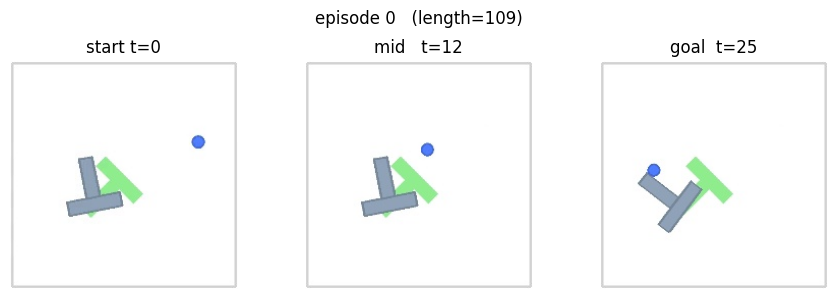

In [8]:
# Default config: episode 0, offset 25
preview_episode(episode_idx=0, start_step=0, goal_offset=25)


ep 0 max offset from t=0: 108


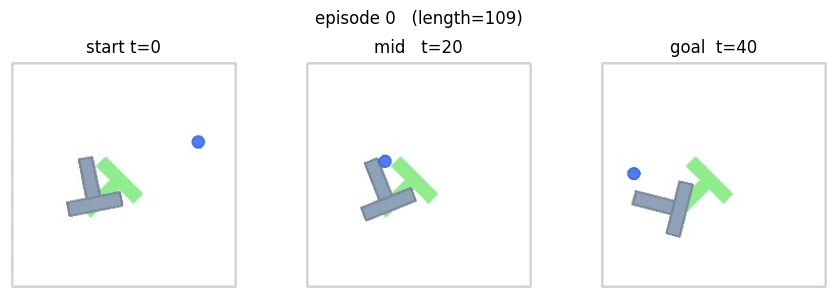

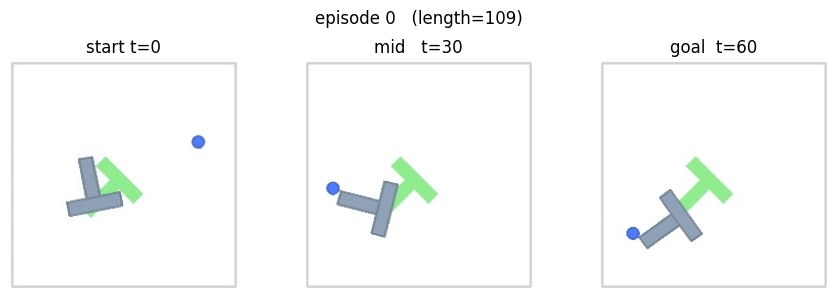

In [9]:
# Same episode, longer horizons
print(f"ep 0 max offset from t=0: {max_goal_offset(0, 0)}")
preview_episode(episode_idx=0, start_step=0, goal_offset=40)
preview_episode(episode_idx=0, start_step=0, goal_offset=60)


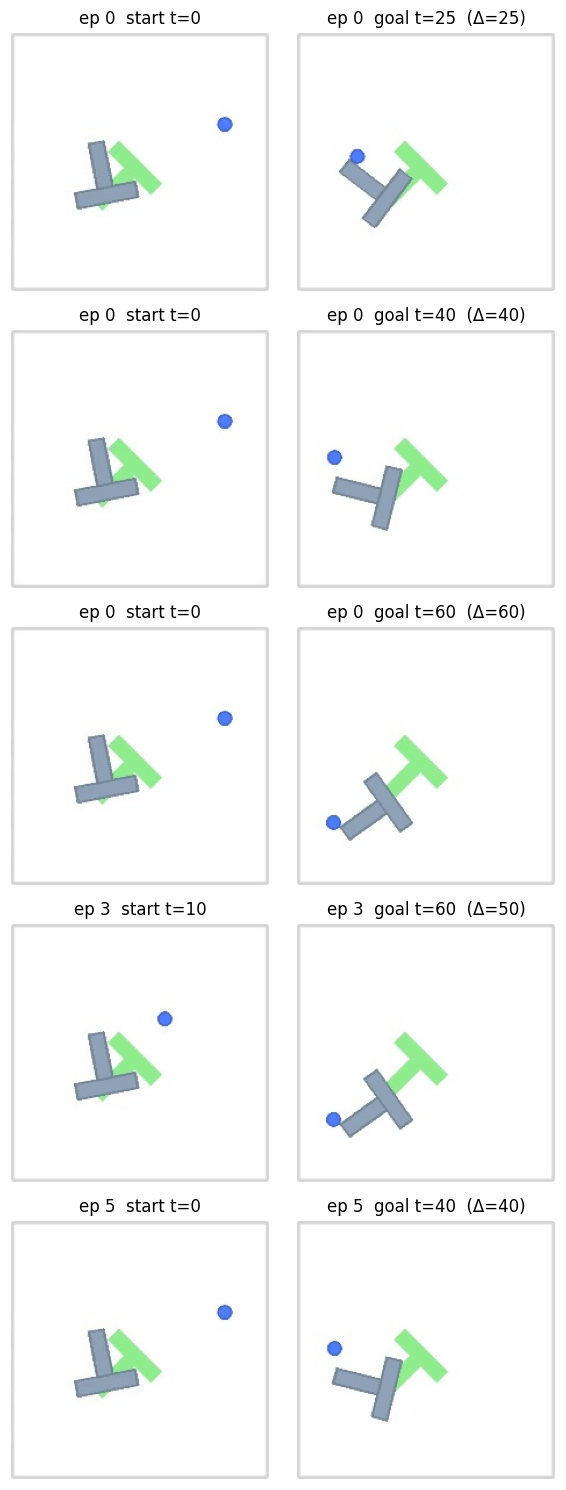

In [10]:
# Side-by-side comparison: easy starting point, harder one further into the episode.
preview_grid([
    (0,  0, 25),
    (0,  0, 40),
    (0,  0, 60),
    (3, 10, 50),
    (5,  0, 40),
])


## Section 2 — Run CEM and save data for manim

Lock the config, build the policy and world for it, run instrumented CEM, draw the iteration view, then dump everything needed for the manim animation.


In [16]:
# --- config -----------------------------------------------------------------
EPISODE_IDX  = 18002
START_STEP   = 0
GOAL_OFFSET  = 40           # bumped from the default 25

# CEM
HORIZON      = 8            # × ACTION_BLOCK = 40 micro-actions per plan
ACTION_BLOCK = 5
NUM_SAMPLES  = 300
N_STEPS      = 30
TOPK         = 30
VAR_SCALE    = 1.0
SEED         = 42

# Output
OUT_DIR = Path(f"/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/p75c/ep{EPISODE_IDX}_off{GOAL_OFFSET}_h{HORIZON}")

if HORIZON * ACTION_BLOCK != GOAL_OFFSET:
    print(f"⚠  HORIZON*ACTION_BLOCK = {HORIZON*ACTION_BLOCK} ≠ GOAL_OFFSET = {GOAL_OFFSET}. "
          "Plan length and goal-frame distance no longer match — cost values will be "
          "comparing latents from different time horizons.")


In [17]:
# --- build policy / solver / world for this config --------------------------
plan_config = swm.PlanConfig(horizon=HORIZON,
                             receding_horizon=HORIZON,
                             action_block=ACTION_BLOCK)

solver = swm.solver.CEMSolver(
    model=cost_model,
    batch_size=1,
    num_samples=NUM_SAMPLES,
    var_scale=VAR_SCALE,
    n_steps=N_STEPS,
    topk=TOPK,
    device=DEVICE,
    seed=SEED,
)

policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process={"action": action_scaler},
    transform={"pixels": img_transform, "goal": img_transform},
)

world = swm.World(
    env_name="swm/PushT-v1",
    num_envs=1,
    max_episode_steps=2 * GOAL_OFFSET,
    history_size=1,
    frame_skip=1,
    image_shape=(IMG_SIZE, IMG_SIZE),
)
world.set_policy(policy)


20:42:26.295 | INFO    (3370556, stable_worldmodel.world) | 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
20:42:26.295 | INFO    (3370556, stable_worldmodel.world) | 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
20:42:26.296 | INFO    (3370556, stable_worldmodel.world) | Box(-1.0, 1.0, (1, 2), float32)
20:42:26.296 | INFO    (3370556, stable_worldmodel.world) | 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
20:42:26.296 | INFO    (3370556, stable_worldmodel.world) | Dict('proprio': Box(0.0, 512.0, (1, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]], (1, 7), float64))
20:42:26.296 | INFO    (3370556, stable_worldmodel.world) | ⚗️ ⚗️ ⚗️ Variation space ⚗️ ⚗️ ⚗️


agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

agent (image px): [ 92.3125 192.9375]


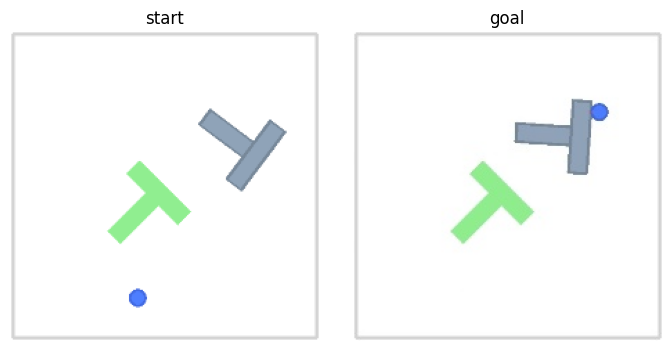

In [18]:
# --- reset world to the chosen dataset episode + set goal -------------------
def setup_world_for_episode(world, dataset, episode_idx, start_step, goal_offset, callables):
    """
    Replicates the relevant chunk of world.evaluate_from_dataset() for a single env.
    Returns the loaded chunk plus the (pre-broadcast) init_step / goal_step dicts.
    """
    ep_idx_arr      = np.array([episode_idx])
    start_steps_arr = np.array([start_step])
    end_steps       = start_steps_arr + goal_offset

    data    = dataset.load_chunk(ep_idx_arr, start_steps_arr, end_steps)
    columns = dataset.column_names

    init_per: dict[str, list[Any]] = defaultdict(list)
    goal_per: dict[str, list[Any]] = defaultdict(list)
    for ep in data:
        for col in columns:
            if col.startswith("goal"):
                continue
            if col.startswith("pixels"):
                ep[col] = ep[col].permute(0, 2, 3, 1)
            if not isinstance(ep[col], (torch.Tensor, np.ndarray)):
                continue
            init_d, goal_d = ep[col][0], ep[col][-1]
            if isinstance(init_d, torch.Tensor):
                init_d, goal_d = init_d.numpy(), goal_d.numpy()
            init_per[col].append(init_d)
            goal_per[col].append(goal_d)

    init_step = {k: np.stack(v) for k, v in deepcopy(init_per).items()}
    goal_step = {("goal" if k == "pixels" else f"goal_{k}"): np.stack(v)
                 for k, v in goal_per.items()}

    seeds = init_step.get("seed")
    variations = {k.removeprefix("variation."): v
                  for k, v in init_step.items() if k.startswith("variation.")}

    options = [{} for _ in range(world.num_envs)]
    if variations:
        for i in range(world.num_envs):
            options[i]["variation"] = list(variations.keys())
            options[i]["variation_values"] = {k: v[i] for k, v in variations.items()}

    init_step_for_reset = deepcopy(init_step)
    init_step_for_reset.update(deepcopy(goal_step))
    world.reset(seed=seeds, options=options)

    # Apply callables (sets pusher + T pose, sets goal pose)
    for i, env in enumerate(world.envs.unwrapped.envs):
        env_unwrapped = env.unwrapped
        for spec in callables:
            method = getattr(env_unwrapped, spec["method"], None)
            if method is None:
                continue
            prepared = {}
            for name, ad in spec.get("args", {}).items():
                val = ad.get("value", None)
                if ad.get("in_dataset", True):
                    if val not in init_step_for_reset:
                        continue
                    prepared[name] = deepcopy(init_step_for_reset[val][i])
                else:
                    prepared[name] = val
            method(**prepared)

    # Broadcast init/goal to (n_envs, history, ...) and write into world.infos
    shape_prefix = world.infos["pixels"].shape[:2]
    init_b = {k: np.broadcast_to(v[:, None], shape_prefix + v.shape[1:])
              for k, v in init_step.items()}
    goal_b = {k: np.broadcast_to(v[:, None], shape_prefix + v.shape[1:])
              for k, v in goal_step.items()}
    world.infos.update(deepcopy(init_b))
    world.infos.update(deepcopy(goal_b))

    return data, init_step, goal_step

data, init_step, goal_step = setup_world_for_episode(
    world, ds, EPISODE_IDX, START_STEP, GOAL_OFFSET, CALLABLES,
)

# canvas we'll overlay onto, goal frame we want to reach
canvas   = world.envs.render()[0]            # (224, 224, 3) uint8
goal_img = goal_step["goal"][0]               # (224, 224, 3) uint8

# pusher start in image coords (taken from dataset state, not re-rendered)
row0 = ep_starts[EPISODE_IDX]
start_state  = ds[row0 + START_STEP]["state"].squeeze(0).cpu().numpy()
goal_state   = ds[row0 + START_STEP + GOAL_OFFSET]["state"].squeeze(0).cpu().numpy()
agent_xy_img = start_state[:2] * SCALE
print("agent (image px):", agent_xy_img)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
axs[0].imshow(canvas);   axs[0].set_title("start"); axs[0].axis("off")
axs[1].imshow(goal_img); axs[1].set_title("goal");  axs[1].axis("off")
plt.tight_layout(); plt.show()


In [19]:
# --- run instrumented CEM (records per-iter internals) ----------------------
def run_instrumented_cem(world, init_action=None):
    info_dict = world.policy._prepare_info(world.infos)

    s = world.policy.solver
    mean, var = s.init_action_distrib(init_action)
    mean, var = mean.to(s.device), var.to(s.device)

    history = {k: [] for k in ["candidates", "costs", "topk_inds",
                               "topk_candidates", "means", "vars"]}

    # We only use total_envs=1 here.
    bs = s.n_envs
    batch_mean, batch_var = mean[:bs], var[:bs]

    expanded = {}
    for k, v in info_dict.items():
        vb = v[:bs]
        if torch.is_tensor(v):
            vb = vb.unsqueeze(1).expand(bs, s.num_samples, *vb.shape[1:])
        elif isinstance(v, np.ndarray):
            vb = np.repeat(vb[:, None, ...], s.num_samples, axis=1)
        expanded[k] = vb

    t0 = time.time()
    for step in range(s.n_steps):
        cands = torch.randn(bs, s.num_samples, s.horizon, s.action_dim,
                            generator=s.torch_gen, device=s.device)
        cands = cands * batch_var.unsqueeze(1) + batch_mean.unsqueeze(1)
        cands[:, 0] = batch_mean   # keep current mean as one of the samples

        costs = s.model.get_cost(expanded.copy(), cands)
        topk_vals, topk_inds = torch.topk(costs, k=s.topk, dim=1, largest=False)
        b_idx      = torch.arange(bs, device=s.device).unsqueeze(1).expand(-1, s.topk)
        topk_cands = cands[b_idx, topk_inds]

        batch_mean = topk_cands.mean(dim=1)
        batch_var  = topk_cands.std(dim=1)   # std despite the name — keeping consistent w/ original

        history["candidates"     ].append(cands.detach().cpu())
        history["costs"          ].append(costs.detach().cpu())
        history["topk_inds"      ].append(topk_inds.detach().cpu())
        history["topk_candidates"].append(topk_cands.detach().cpu())
        history["means"          ].append(batch_mean.detach().cpu())
        history["vars"           ].append(batch_var.detach().cpu())

    elite_cost = topk_vals.mean().item()
    print(f"CEM solve: {time.time() - t0:.2f}s   final elite cost = {elite_cost:.4f}")
    return history

history = run_instrumented_cem(world)


CEM solve: 7.47s   final elite cost = 2.3255


In [20]:
# --- project candidates from action-space to image-space (pixels) -----------
H, N, K        = HORIZON, NUM_SAMPLES, TOPK
A_BLOCK, A_DIM = ACTION_BLOCK, 2
N_ACTS         = H * A_BLOCK

def candidates_to_image_xy(cands, start_xy_img):
    """(batch, H, A_BLOCK*A_DIM) standardized  ->  (batch, N_ACTS, 2) image px."""
    a = cands.detach().cpu().numpy()
    a = a.reshape(a.shape[0], N_ACTS, A_DIM)
    a = action_scaler.inverse_transform(a.reshape(-1, A_DIM))
    a = a.reshape(-1, N_ACTS, A_DIM)
    deltas_img = a * act_scale * SCALE
    return np.cumsum(deltas_img, axis=1) + start_xy_img[None, None, :]

# Build per-iteration arrays in image coords — what we plot and what manim consumes.
paths_all_per, paths_elite_per, paths_mean_per = [], [], []
costs_per, topk_inds_per, cum_sigma_per        = [], [], []

for it in range(N_STEPS):
    cands   = history["candidates"     ][it][0]
    costs   = history["costs"          ][it][0].numpy()
    elites  = history["topk_candidates"][it][0]
    mean_b  = history["means"          ][it][0:1]   # keep batch dim
    var_b   = history["vars"           ][it][0]

    paths_all_per.append(  candidates_to_image_xy(cands,  agent_xy_img))
    paths_elite_per.append(candidates_to_image_xy(elites, agent_xy_img))
    paths_mean_per.append( candidates_to_image_xy(mean_b, agent_xy_img)[0])
    costs_per.append(costs)
    topk_inds_per.append(history["topk_inds"][it][0].numpy())

    sigma_norm    = var_b.numpy().reshape(N_ACTS, A_DIM)
    sigma_img     = sigma_norm * action_scaler.scale_ * act_scale * SCALE
    cum_sigma_per.append(np.sqrt(np.cumsum(sigma_img ** 2, axis=0)))

paths_all_per   = np.stack(paths_all_per)     # (n_steps, N, N_ACTS, 2)
paths_elite_per = np.stack(paths_elite_per)   # (n_steps, K, N_ACTS, 2)
paths_mean_per  = np.stack(paths_mean_per)    # (n_steps, N_ACTS, 2)
costs_per       = np.stack(costs_per)         # (n_steps, N)
topk_inds_per   = np.stack(topk_inds_per)     # (n_steps, K)
cum_sigma_per   = np.stack(cum_sigma_per)     # (n_steps, N_ACTS, 2)

print("paths_all   :", paths_all_per.shape)
print("paths_elite :", paths_elite_per.shape)
print("paths_mean  :", paths_mean_per.shape)
print("costs       :", costs_per.shape)


paths_all   : (30, 300, 40, 2)
paths_elite : (30, 30, 40, 2)
paths_mean  : (30, 40, 2)
costs       : (30, 300)


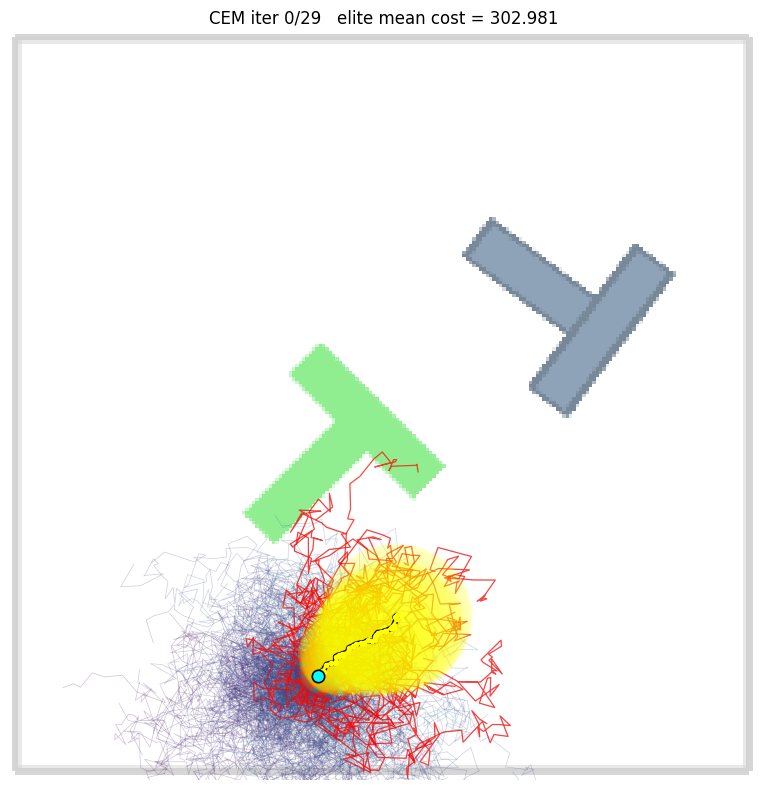

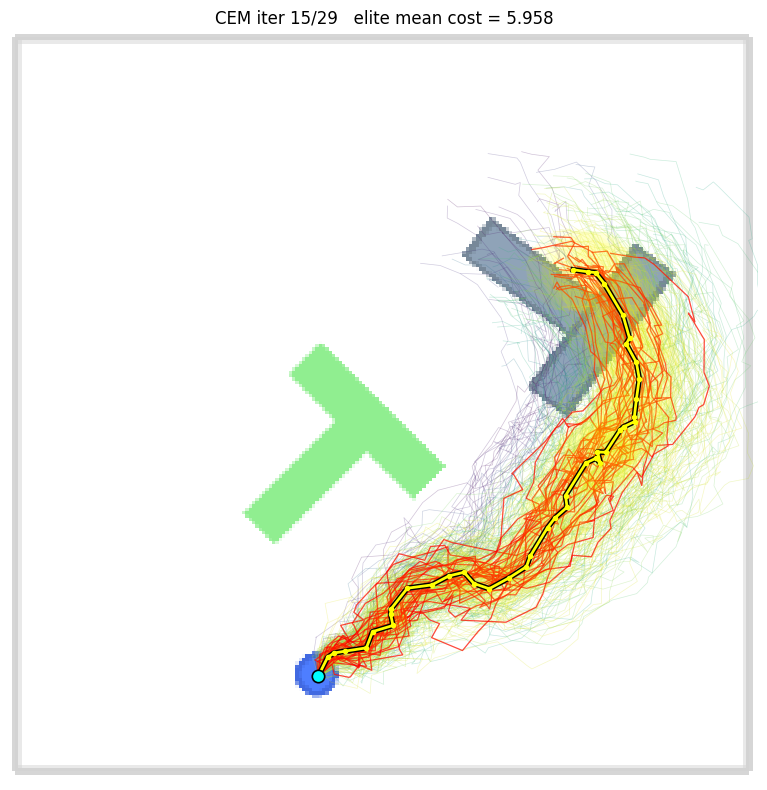

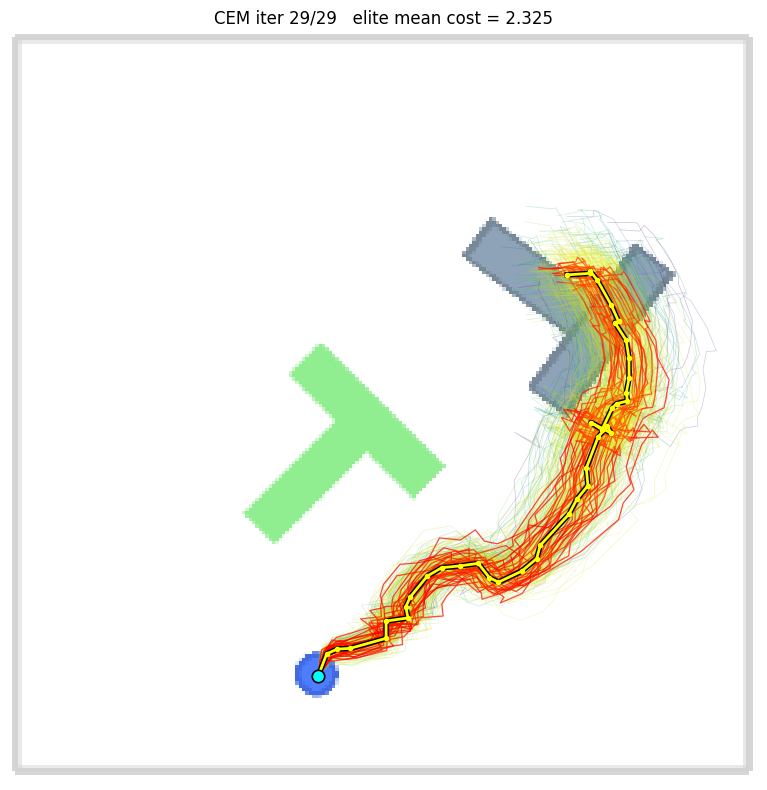

In [21]:
# --- plot a single CEM iteration (same look as the original notebook) -------
def plot_cem_iteration(iter_idx, ax=None, show=True):
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(canvas)

    paths_all   = paths_all_per  [iter_idx]
    paths_elite = paths_elite_per[iter_idx]
    path_mean   = paths_mean_per [iter_idx]
    costs       = costs_per      [iter_idx]
    cum_sigma   = cum_sigma_per  [iter_idx]

    start_pt = np.broadcast_to(agent_xy_img[None, None, :], (N, 1, 2))
    segs_all = np.concatenate([start_pt, paths_all], axis=1)
    segs_el  = np.concatenate([start_pt[:K], paths_elite], axis=1)
    segs_m   = np.concatenate([agent_xy_img[None, :], path_mean])

    order = np.argsort(-costs)
    cmap  = plt.get_cmap("viridis_r")
    norm  = plt.Normalize(vmin=costs.min(), vmax=costs.max())
    ax.add_collection(LineCollection(segs_all[order], colors=cmap(norm(costs))[order],
                                     linewidths=0.5, alpha=0.25))
    ax.add_collection(LineCollection(segs_el, colors="red", linewidths=0.9, alpha=0.7))
    ax.plot(segs_m[:, 0], segs_m[:, 1], "-",  color="black",  linewidth=4, zorder=4)
    ax.plot(segs_m[:, 0], segs_m[:, 1], "-o", color="yellow", linewidth=2,
            markersize=3, zorder=5)
    for i in range(N_ACTS):
        ax.add_patch(Ellipse(xy=path_mean[i],
                             width =2 * cum_sigma[i, 0],
                             height=2 * cum_sigma[i, 1],
                             facecolor="yellow", edgecolor="none",
                             alpha=0.08, zorder=3))
    ax.scatter([agent_xy_img[0]], [agent_xy_img[1]],
               s=80, c="cyan", edgecolors="black", linewidths=1.2, zorder=6)
    ax.set_xlim(0, IMG_SIZE); ax.set_ylim(IMG_SIZE, 0); ax.axis("off")
    elite_mean = costs[topk_inds_per[iter_idx]].mean()
    ax.set_title(f"CEM iter {iter_idx}/{N_STEPS - 1}   elite mean cost = {elite_mean:.3f}")
    if created and show:
        plt.tight_layout(); plt.show()

# Three snapshots: cloud → narrowing → converged
plot_cem_iteration(0)
plot_cem_iteration(N_STEPS // 2)
plot_cem_iteration(N_STEPS - 1)


In [22]:
# --- save everything for manim ---------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
frames_dir = OUT_DIR / "frames"
frames_dir.mkdir(exist_ok=True)

# 1. start canvas + goal frame
plt.imsave(OUT_DIR / "canvas.png", canvas)
plt.imsave(OUT_DIR / "goal.png",   goal_img)

# 2. per-iteration arrays (image-space paths + raw distributions)
np.savez_compressed(
    OUT_DIR / "iterations.npz",
    paths_all   = paths_all_per  .astype(np.float32),
    paths_elite = paths_elite_per.astype(np.float32),
    paths_mean  = paths_mean_per .astype(np.float32),
    costs       = costs_per      .astype(np.float32),
    topk_inds   = topk_inds_per  .astype(np.int32),
    cum_sigma   = cum_sigma_per  .astype(np.float32),
    # raw action-space stats (in case manim wants to re-derive things)
    raw_means   = torch.stack(history["means"]).cpu().numpy().astype(np.float32),
    raw_vars    = torch.stack(history["vars" ]).cpu().numpy().astype(np.float32),
)

# 3. config / metadata
config_out = {
    "episode_idx":         EPISODE_IDX,
    "start_step":          START_STEP,
    "goal_offset":         GOAL_OFFSET,
    "horizon":             HORIZON,
    "action_block":        ACTION_BLOCK,
    "n_acts_per_plan":     N_ACTS,
    "num_samples":         NUM_SAMPLES,
    "n_steps":             N_STEPS,
    "topk":                TOPK,
    "var_scale":           VAR_SCALE,
    "seed":                SEED,
    "img_size":            IMG_SIZE,
    "pusht_native":        PUSHT_NATIVE,
    "scale":               float(SCALE),
    "agent_xy_img":        agent_xy_img.tolist(),
    "start_state":         start_state.tolist(),
    "goal_state":          goal_state .tolist(),
    "act_scale":           act_scale.tolist(),
    "action_scaler_mean":  action_scaler.mean_ .tolist(),
    "action_scaler_scale": action_scaler.scale_.tolist(),
}
with open(OUT_DIR / "config.json", "w") as f:
    json.dump(config_out, f, indent=2)

# 4. per-iteration PNGs (handy for scrubbing / sanity-check)
for it in range(N_STEPS):
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_cem_iteration(it, ax=ax, show=False)
    fig.savefig(frames_dir / f"{it:03d}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"\nsaved to {OUT_DIR.resolve()}")
print("  canvas.png, goal.png")
print("  iterations.npz")
print("  config.json")
print(f"  frames/000.png … {N_STEPS - 1:03d}.png")



saved to /home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/p75c/ep18002_off40_h8
  canvas.png, goal.png
  iterations.npz
  config.json
  frames/000.png … 029.png


## Plan 0 saved — what's on disk

```
cem_run_data/ep0_off40_h8/
├── canvas.png            # start frame (IMG_SIZE × IMG_SIZE × 3, uint8)
├── goal.png              # goal frame
├── iterations.npz        # per-iteration arrays for the animation
│     paths_all     (n_steps, N, N_ACTS, 2)    all candidate paths in image px
│     paths_elite   (n_steps, K, N_ACTS, 2)    top-K paths
│     paths_mean    (n_steps,    N_ACTS, 2)    mean path
│     costs         (n_steps, N)               cost of every candidate
│     topk_inds     (n_steps, K)               which candidates became elites
│     cum_sigma     (n_steps, N_ACTS, 2)       per-step std along the mean path
│     raw_means     (n_steps, 1, H, A_BLOCK*A_DIM)  raw action-space dist mean
│     raw_vars      (n_steps, 1, H, A_BLOCK*A_DIM)  raw action-space dist std
├── config.json           # episode/CEM config + calibration constants
└── frames/000.png … NNN.png    PNG per iteration (matches the matplotlib view)
```


## Section 3 — Follow the plan in the real env

Take the final CEM mean plan, un-standardize, and step the env one micro-action at a time, rendering and saving every frame. Goal stays pinned in `world.infos` so the env state is ready for a re-plan afterwards.

Outputs to `<OUT_DIR>_rollout/`:
- `frame_000.png … frame_NNN.png` — one PNG per env step (frame 0 is the start)
- `rollout.npz` — `frames`, `states`, `actions` stacked into arrays


In [26]:
from copy import deepcopy

In [27]:
# --- execute the final plan in the real env, save every rendered frame ------
OUT_DIR_ROLLOUT = OUT_DIR.parent / (OUT_DIR.name + "_rollout")
OUT_DIR_ROLLOUT.mkdir(parents=True, exist_ok=True)

# Final CEM plan in standardized space -> un-standardized env actions.
final_plan_std = history["means"][-1].numpy()                  # (1, H, A_BLOCK*A_DIM)
plan_micro_std = final_plan_std.reshape(1, N_ACTS, A_DIM)      # (1, N_ACTS, 2)
plan_micro     = action_scaler.inverse_transform(
                    plan_micro_std.reshape(-1, A_DIM)
                 ).reshape(1, N_ACTS, A_DIM)                    # env-unit actions

# Step the env, record frame + state + action at every micro-action.
rollout_frames = [world.envs.render()[0].copy()]
rollout_states = ([deepcopy(world.infos["state"][0, -1])]
                  if "state" in world.infos else [])
rollout_acts   = []

for t in range(N_ACTS):
    a = plan_micro[:, t]            # (1, 2)
    (world.states, world.rewards,
     world.terminateds, world.truncateds,
     world.infos) = world.envs.step(a)
    # re-pin the goal so subsequent CEM calls still see it
    world.infos.update(deepcopy(goal_step))

    rollout_frames.append(world.envs.render()[0].copy())
    rollout_acts.append(a[0].copy())
    if "state" in world.infos:
        rollout_states.append(world.infos["state"][0, -1].copy())

rollout_frames = np.stack(rollout_frames)
rollout_acts   = np.stack(rollout_acts)
rollout_states = np.stack(rollout_states) if rollout_states else np.empty((0,))

for t, frame in enumerate(rollout_frames):
    plt.imsave(OUT_DIR_ROLLOUT / f"frame_{t:03d}.png", frame)
np.savez_compressed(
    OUT_DIR_ROLLOUT / "rollout.npz",
    frames  = rollout_frames,
    states  = rollout_states.astype(np.float32),
    actions = rollout_acts.astype(np.float32),
)
print(f"saved {len(rollout_frames)} frames + rollout.npz to {OUT_DIR_ROLLOUT.resolve()}")

# quick visual scrub
snap_ix = np.linspace(0, len(rollout_frames) - 1, 6).astype(int)
fig, axs = plt.subplots(1, len(snap_ix), figsize=(2.2 * len(snap_ix), 2.5))
for ax, t in zip(axs, snap_ix):
    ax.imshow(rollout_frames[t]); ax.set_title(f"t={t}"); ax.axis("off")
plt.suptitle("plan 0 executed in env — snapshots")
plt.tight_layout(); plt.show()


AssertionError: self._autoreset_envs=array([ True])

- Hmm ok no go yet - might want to break this one apart into two notebooks or something - let me pick up tomorrow, I'm not 100% sure I'll need/want to show a replanning phase, probably worth some illustrator/manim action first, and then decide. 

## Section 4 — Re-plan from the new state

The env is now at the end of plan 0; the same goal is still pinned. Run CEM fresh from here and save the bundle in the same layout as plan 0.

Outputs to `<OUT_DIR>_plan1/` (same file layout as plan 0).


In [ ]:
# --- helpers parameterised on canvas / agent / arrays (so we can reuse) -----
def project_history_to_image_space(history_obj, agent_xy):
    out = {k: [] for k in ["paths_all", "paths_elite", "paths_mean",
                           "costs", "topk_inds", "cum_sigma"]}
    for it in range(len(history_obj["candidates"])):
        cands  = history_obj["candidates"     ][it][0]
        costs_ = history_obj["costs"          ][it][0].numpy()
        elites = history_obj["topk_candidates"][it][0]
        mean_b = history_obj["means"          ][it][0:1]
        var_b  = history_obj["vars"           ][it][0]
        out["paths_all"  ].append(candidates_to_image_xy(cands,  agent_xy))
        out["paths_elite"].append(candidates_to_image_xy(elites, agent_xy))
        out["paths_mean" ].append(candidates_to_image_xy(mean_b, agent_xy)[0])
        out["costs"      ].append(costs_)
        out["topk_inds"  ].append(history_obj["topk_inds"][it][0].numpy())
        sigma_norm = var_b.numpy().reshape(N_ACTS, A_DIM)
        sigma_img  = sigma_norm * action_scaler.scale_ * act_scale * SCALE
        out["cum_sigma" ].append(np.sqrt(np.cumsum(sigma_img ** 2, axis=0)))
    return {k: np.stack(v) for k, v in out.items()}

def draw_cem_iteration(iter_idx, canvas_img, agent_xy, proj, n_steps_total,
                       ax=None, show=True):
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(canvas_img)
    paths_all   = proj["paths_all"  ][iter_idx]
    paths_elite = proj["paths_elite"][iter_idx]
    path_mean   = proj["paths_mean" ][iter_idx]
    costs       = proj["costs"      ][iter_idx]
    topk_inds_i = proj["topk_inds"  ][iter_idx]
    cum_sigma   = proj["cum_sigma"  ][iter_idx]

    start_pt = np.broadcast_to(agent_xy[None, None, :], (N, 1, 2))
    segs_all = np.concatenate([start_pt, paths_all], axis=1)
    segs_el  = np.concatenate([start_pt[:K], paths_elite], axis=1)
    segs_m   = np.concatenate([agent_xy[None, :], path_mean])

    order = np.argsort(-costs)
    cmap  = plt.get_cmap("viridis_r")
    norm  = plt.Normalize(vmin=costs.min(), vmax=costs.max())
    ax.add_collection(LineCollection(segs_all[order], colors=cmap(norm(costs))[order],
                                     linewidths=0.5, alpha=0.25))
    ax.add_collection(LineCollection(segs_el, colors="red", linewidths=0.9, alpha=0.7))
    ax.plot(segs_m[:, 0], segs_m[:, 1], "-",  color="black",  linewidth=4, zorder=4)
    ax.plot(segs_m[:, 0], segs_m[:, 1], "-o", color="yellow", linewidth=2,
            markersize=3, zorder=5)
    for i in range(N_ACTS):
        ax.add_patch(Ellipse(xy=path_mean[i],
                             width =2 * cum_sigma[i, 0],
                             height=2 * cum_sigma[i, 1],
                             facecolor="yellow", edgecolor="none",
                             alpha=0.08, zorder=3))
    ax.scatter([agent_xy[0]], [agent_xy[1]], s=80, c="cyan",
               edgecolors="black", linewidths=1.2, zorder=6)
    ax.set_xlim(0, IMG_SIZE); ax.set_ylim(IMG_SIZE, 0); ax.axis("off")
    elite_mean = costs[topk_inds_i].mean()
    ax.set_title(f"CEM iter {iter_idx}/{n_steps_total - 1}   "
                 f"elite mean cost = {elite_mean:.3f}")
    if created and show:
        plt.tight_layout(); plt.show()


In [ ]:
# --- re-plan from the post-rollout env state, save in plan-0 layout ---------
OUT_DIR_PLAN1 = OUT_DIR.parent / (OUT_DIR.name + "_plan1")
(OUT_DIR_PLAN1 / "frames").mkdir(parents=True, exist_ok=True)

# New canvas + agent position. Prefer env state from world.infos; fall back to
# integrating the executed actions if 'state' isn't there.
canvas_1 = world.envs.render()[0]
if "state" in world.infos:
    start_state_1  = world.infos["state"][0, -1].copy()
    agent_xy_img_1 = start_state_1[:2] * SCALE
    print(f"new agent xy (from world.infos['state']): {agent_xy_img_1}")
else:
    delta = (plan_micro[0] * act_scale * SCALE).sum(axis=0)
    agent_xy_img_1 = agent_xy_img + delta
    start_state_1  = np.concatenate([agent_xy_img_1 / SCALE, start_state[2:]])
    print(f"new agent xy (from action integration): {agent_xy_img_1}")

# Fresh CEM solve from the new state (no warm-start)
history_1 = run_instrumented_cem(world, init_action=None)

# Project to image space + preview last iter
proj_1 = project_history_to_image_space(history_1, agent_xy_img_1)
draw_cem_iteration(0,           canvas_1, agent_xy_img_1, proj_1, N_STEPS)
draw_cem_iteration(N_STEPS // 2, canvas_1, agent_xy_img_1, proj_1, N_STEPS)
draw_cem_iteration(N_STEPS - 1,  canvas_1, agent_xy_img_1, proj_1, N_STEPS)

# Save plan_1 bundle — exact same layout as plan 0
plt.imsave(OUT_DIR_PLAN1 / "canvas.png", canvas_1)
plt.imsave(OUT_DIR_PLAN1 / "goal.png",   goal_img)
np.savez_compressed(
    OUT_DIR_PLAN1 / "iterations.npz",
    paths_all   = proj_1["paths_all"  ].astype(np.float32),
    paths_elite = proj_1["paths_elite"].astype(np.float32),
    paths_mean  = proj_1["paths_mean" ].astype(np.float32),
    costs       = proj_1["costs"      ].astype(np.float32),
    topk_inds   = proj_1["topk_inds"  ].astype(np.int32),
    cum_sigma   = proj_1["cum_sigma"  ].astype(np.float32),
    raw_means   = torch.stack(history_1["means"]).cpu().numpy().astype(np.float32),
    raw_vars    = torch.stack(history_1["vars" ]).cpu().numpy().astype(np.float32),
)
config_out_1 = dict(config_out)
config_out_1.update({
    "plan_idx":     1,
    "agent_xy_img": agent_xy_img_1.tolist(),
    "start_state":  start_state_1.tolist(),
    # goal_state unchanged
})
with open(OUT_DIR_PLAN1 / "config.json", "w") as f:
    json.dump(config_out_1, f, indent=2)

for it in range(N_STEPS):
    fig, ax = plt.subplots(figsize=(8, 8))
    draw_cem_iteration(it, canvas_1, agent_xy_img_1, proj_1, N_STEPS,
                       ax=ax, show=False)
    fig.savefig(OUT_DIR_PLAN1 / "frames" / f"{it:03d}.png",
                dpi=150, bbox_inches="tight")
    plt.close(fig)
print(f"saved plan_1 bundle to {OUT_DIR_PLAN1.resolve()}")


## Final on-disk layout

```
cem_run_data/
├── ep0_off40_h8/                # plan 0 (Section 2)
│   ├── canvas.png, goal.png
│   ├── iterations.npz           # per-iteration arrays (see Section 2 wrap-up)
│   ├── config.json
│   └── frames/000.png … NNN.png
├── ep0_off40_h8_rollout/        # Section 3 — plan 0 executed in env
│   ├── frame_000.png … frame_NNN.png
│   └── rollout.npz              # frames, states, actions
└── ep0_off40_h8_plan1/          # Section 4 — re-plan from the new state
    ├── canvas.png, goal.png
    ├── iterations.npz
    ├── config.json
    └── frames/000.png … NNN.png
```

For the manim scene, the timeline is:
1. `plan_0` iterations animation (cloud collapses to a yellow path on `canvas.png`).
2. The yellow path "executes" — swap to `rollout/frame_*.png` as the pusher and T move; this is your evidence the JEPA-derived plan transfers to the real env.
3. The pusher arrives at the post-rollout pose (`plan_1/canvas.png`). Re-run the `plan_1` iterations animation from this new background.

`config.json` in each plan dir gives you the matching `agent_xy_img` (cyan start dot), `start_state`, and `goal_state` in PushT-native coords.
